# Chapter 5 — Bounded Confidence Model
**Modeling Social Behavior** | Smaldino

---

### What this notebook does

We build the **Bounded Confidence (BC)** model which is an extension of the positive
influence model (Exercise 5.2) that adds one key gate:

> Two agents only influence each other if their opinion difference is **strictly
> less than** the confidence threshold $d$. If $|x_1 - x_2| \geq d$, nothing happens.

This single change has dramatic consequences. Consensus is no longer inevitable.
Depending on $d$, the population may fragment into several stable **opinion cliques** —
clusters of agents who all share the same opinion and never interact with agents
outside their cluster, because the gap always exceeds $d$.

### Two structural additions vs. Exercise 5.2

| Addition | What it does |
|---|---|
| `confidence_threshold` (`d`) | Global parameter: maximum gap that allows influence |
| `spatial_interactions` toggle | Switches between well-mixed (random partner) and spatial (4 neighbors only) |

### Batch experiment
We replicate the book's Figure 5.4A batch experiment exactly:
- Sweep `d` from 0.02 to 1.0 in steps of 0.02 (50 values)
- 30 replications per value
- 80,000 ticks per run, $\gamma = 0.5$
- Record the number of emergent cliques per run


---
## 1. Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm    # progress bar for the batch run

np.random.seed(42)


---
## 2. Global Parameters

Two parameters are new compared to Exercise 5.2:

**`confidence_threshold` ($d$):**  
The maximum opinion difference that permits positive influence. Agents with a gap
of exactly $d$ or larger do not interact — the gate is *strictly less than*, just
as in the original model (`abs(x1 - x2) < confidence-threshold`).

**`spatial_interactions`:**  
When `False` (well-mixed), the partner is drawn from the entire population.  
When `True` (spatial), the partner is drawn from the agent's four von Neumann
neighbors on the toroidal grid. This is the version shown in Section 5.3.3.

### Why toroidal boundaries?

The grid "wraps around" at the edges, so every agent always has exactly four
neighbors and there are no edge effects. An agent on the rightmost column can
interact with an agent on the leftmost column.


In [2]:
# ── GLOBAL PARAMETERS ──────────────────────────────────────────────────────

L                    = 21        # grid side length; N = L*L agents
N                    = L * L     # total agents = 441
learning_rate        = 0.3       # γ: step size fraction, must be in (0, 0.5]
confidence_threshold = 0.5       # d: max opinion gap that allows influence
n_ticks              = 10_000    # interaction events per single run
record_every         = 200       # snapshot frequency for scatterplot

# Toggle: set to True for spatial (neighbors only), False for well-mixed
spatial_interactions = False

print(f"Grid:  {L}×{L}  →  N = {N} agents")
print(f"γ = {learning_rate},  d = {confidence_threshold},  ticks = {n_ticks:,}")
print(f"Spatial interactions: {spatial_interactions}")


Grid:  21×21  →  N = 441 agents
γ = 0.3,  d = 0.5,  ticks = 10,000
Spatial interactions: False


---
## 3. Initialization

### Agent variable: `opinions`
Each agent gets a single opinion drawn uniformly from $[-1, 1]$. Unlike the negative
influence notebook, we do **not** store `initial_opinions` here. This file exactly
matches the book's BC-only model, which doesn't use that variable.

### Global structure: `neighbor_map`
For spatial interactions, we precompute each agent's four von Neumann neighbors once
and store them in a dictionary. This avoids recalculating grid positions every tick.

Agent $i$ lives at grid row $r = i \div L$ and column $c = i \bmod L$.  
Its neighbors are:

$$\text{up} = (r-1 \bmod L) \cdot L + c \qquad
  \text{down} = (r+1 \bmod L) \cdot L + c$$
$$\text{left} = r \cdot L + (c-1 \bmod L) \qquad
  \text{right} = r \cdot L + (c+1 \bmod L)$$


In [3]:
def build_neighbor_map(L):
    """
    Precompute the von Neumann (4-neighbor) map for an L×L toroidal grid.

    Parameters
    ----------
    L : int
        Grid side length (global parameter)

    Returns
    -------
    neighbors : dict  { agent_index : [up, down, left, right] }
        Global structure: every agent's four neighbor indices.
        The modulo operation implements toroidal (wraparound) boundaries.
    """
    neighbors = {}
    for i in range(L * L):
        r, c = divmod(i, L)                           # local: row and column of agent i
        up    = ((r - 1) % L) * L + c                # local: neighbor above (wraps)
        down  = ((r + 1) % L) * L + c                # local: neighbor below (wraps)
        left  =  r * L + (c - 1) % L                 # local: neighbor to the left (wraps)
        right =  r * L + (c + 1) % L                 # local: neighbor to the right (wraps)
        neighbors[i] = [up, down, left, right]
    return neighbors


def initialize(L, seed=None):
    """
    Create initial agent opinions and the neighbor map for an L×L population.

    Parameters
    ----------
    L    : int          Grid side length (global parameter)
    seed : int or None  RNG seed for reproducibility

    Returns
    -------
    opinions     : np.ndarray shape (N,)  — agent variable: opinion in [-1, 1]
    neighbor_map : dict                   — global structure: precomputed neighbors
    """
    rng      = np.random.default_rng(seed)
    opinions = rng.uniform(-1.0, 1.0, size=L * L)   # agent variable
    return opinions, build_neighbor_map(L)


# ── RUN INITIALIZATION ──────────────────────────────────────────────────────

opinions, neighbor_map = initialize(L, seed=42)

print(f"Initialized {N} agents")
print(f"  Opinion range : [{opinions.min():.4f}, {opinions.max():.4f}]")
print(f"  Mean          : {opinions.mean():.4f}   (expected ≈ 0)")
print(f"  Std dev       : {opinions.std():.4f}   (expected ≈ 0.577 for Uniform[-1,1])")
print()
# Verify the neighbor map with a corner agent and a center agent
corner = 0
center = N // 2
print(f"Neighbors of agent {corner} (top-left corner): {neighbor_map[corner]}")
print(f"Neighbors of agent {center} (center):          {neighbor_map[center]}")


Initialized 441 agents
  Opinion range : [-0.9891, 0.9982]
  Mean          : -0.0028   (expected ≈ 0)
  Std dev       : 0.5814   (expected ≈ 0.577 for Uniform[-1,1])

Neighbors of agent 0 (top-left corner): [420, 21, 20, 1]
Neighbors of agent 220 (center):          [199, 241, 219, 221]


---
## 4. The Update Rule — Bounded Confidence Gate + Equation 5.1

The BC update rule is exactly two things:

**Step 1 — Gate check:** Only proceed if $|x_1 - x_2| < d$.  
This is the entire new addition versus Exercise 5.2.

**Step 2 — Positive influence (Equation 5.1):** if the gate passes, apply:
$$x_1 \leftarrow x_1 + \gamma(x_2 - x_1)$$
$$x_2 \leftarrow x_2 + \gamma(x_1 - x_2)$$

If the gate does **not** pass, the two agents simply do nothing. Their opinions
are unchanged.

### Why this produces cliques

Once a gap between two groups of agents grows large enough to exceed $d$, those
groups can never reduce their gap because they never interact. The gap can only
grow or stay the same, never shrink. So once cliques are separated by a gap $\geq d$,
that separation is permanent and the cliques are stable forever.


In [4]:
def bc_update(opinions, i, j, gamma, d):
    """
    Bounded confidence update for one interaction event.

    Applies Equation 5.1 (positive influence) only if the absolute opinion
    difference between agents i and j is strictly less than the confidence
    threshold d. Otherwise, does nothing.

    Parameters
    ----------
    opinions : np.ndarray  — agent variable array, modified in place
    i, j     : int         — indices of the two interacting agents (local)
    gamma    : float       — learning rate (global parameter)
    d        : float       — confidence threshold (global parameter)
    """
    x1  = opinions[i]       # local: opinion of focal agent
    x2  = opinions[j]       # local: opinion of partner
    gap = abs(x1 - x2)      # local: absolute opinion difference

    # Gate: only influence if within the confidence threshold
    if gap < d:
        # Equation 5.1 — both agents move toward each other
        opinions[i] = x1 + gamma * (x2 - x1)
        opinions[j] = x2 + gamma * (x1 - x2)
    # else: gap >= d → agents ignore each other, no update


# ── SANITY CHECKS ────────────────────────────────────────────────────────────

d_test = 0.5

print("=== Should update (gap < d) ===")
ops = np.array([-0.1, 0.3])
gap = abs(ops[1] - ops[0])
print(f"  Opinions: {ops},  gap = {gap:.2f} < d={d_test} → update fires")
mean_before = ops.mean()
bc_update(ops, 0, 1, gamma=0.3, d=d_test)
print(f"  After: {np.round(ops, 4)},  mean = {ops.mean():.4f}  (was {mean_before:.4f}, conserved ✓)")

print()
print("=== Should NOT update (gap >= d) ===")
ops2 = np.array([-0.4, 0.4])
gap2 = abs(ops2[1] - ops2[0])
print(f"  Opinions: {ops2},  gap = {gap2:.2f} >= d={d_test} → no update")
ops2_copy = ops2.copy()
bc_update(ops2, 0, 1, gamma=0.3, d=d_test)
print(f"  After: {np.round(ops2, 4)}  (unchanged ✓)" if np.allclose(ops2, ops2_copy) else "  ❌ Should not have changed!")


=== Should update (gap < d) ===
  Opinions: [-0.1  0.3],  gap = 0.40 < d=0.5 → update fires
  After: [0.02 0.18],  mean = 0.1000  (was 0.1000, conserved ✓)

=== Should NOT update (gap >= d) ===
  Opinions: [-0.4  0.4],  gap = 0.80 >= d=0.5 → no update
  After: [-0.4  0.4]  (unchanged ✓)


---
## 5. The Simulation Loop

At each tick:

1. A focal agent is chosen uniformly at random from all $N$ agents
2. The interaction partner is chosen:
   - **Well-mixed** (`spatial_interactions=False`): any other agent at random
   - **Spatial** (`spatial_interactions=True`): one of the four von Neumann neighbors
3. The BC gate is checked; if $|x_1 - x_2| < d$, Equation 5.1 is applied

We record opinion snapshots every `record_every` ticks for the scatterplot, and
track variance at every tick to watch convergence (or lack thereof).


In [5]:
def run_simulation(opinions, neighbor_map, gamma, d,
                   n_ticks, record_every, spatial_interactions,
                   seed=None):
    """
    Run the BC model for n_ticks interaction events.

    Parameters  (all global parameters passed in explicitly)
    ----------
    opinions             : np.ndarray  — agent variable, modified in place
    neighbor_map         : dict        — global structure
    gamma                : float       — learning rate
    d                    : float       — confidence threshold
    n_ticks              : int         — total interaction events
    record_every         : int         — snapshot frequency
    spatial_interactions : bool        — well-mixed vs. spatial

    Returns
    -------
    history       : list of (tick, agent_idx, opinion) — scatterplot data
    var_over_time : list of float                       — variance per tick
    """
    N   = len(opinions)
    rng = np.random.default_rng(seed)

    history       = []    # local: opinion snapshots for scatterplot
    var_over_time = []    # local: population variance at each tick

    for tick in range(n_ticks + 1):

        # ── RECORD SNAPSHOT ───────────────────────────────────────────────
        if tick % record_every == 0:
            for idx in range(N):
                history.append((tick, idx, opinions[idx]))
        var_over_time.append(opinions.var())

        if tick == n_ticks:
            break    # stop after final recording; no extra interaction

        # ── CHOOSE FOCAL AGENT ────────────────────────────────────────────
        i = int(rng.integers(0, N))                    # local: focal agent index

        # ── CHOOSE INTERACTION PARTNER ────────────────────────────────────
        if spatial_interactions:
            # Spatial: partner must be one of the four von Neumann neighbors
            j = int(rng.choice(neighbor_map[i]))       # local: neighbor index
        else:
            # Well-mixed: partner is any other agent
            other = np.delete(np.arange(N), i)         # local: all except i
            j = int(rng.choice(other))                 # local: chosen partner

        # ── APPLY BC UPDATE ───────────────────────────────────────────────
        bc_update(opinions, i, j, gamma=gamma, d=d)

    return history, var_over_time


# ── QUICK TEST RUN ───────────────────────────────────────────────────────────

opinions, neighbor_map = initialize(L, seed=42)
initial_mean = opinions.mean()

print("Running BC model...")
history, var_traj = run_simulation(
    opinions, neighbor_map,
    gamma=learning_rate, d=confidence_threshold,
    n_ticks=n_ticks, record_every=record_every,
    spatial_interactions=spatial_interactions,
    seed=42
)

print(f"Complete. d = {confidence_threshold},  {n_ticks:,} ticks")
print(f"  Initial mean    : {initial_mean:.4f}")
print(f"  Final mean      : {opinions.mean():.4f}  (conserved within interacting cliques ✓)")
print(f"  Initial variance: {var_traj[0]:.4f}")
print(f"  Final variance  : {var_traj[-1]:.4f}  (> 0 means cliques persist, not full consensus)")
print(f"  Final op range  : [{opinions.min():.4f}, {opinions.max():.4f}]")


Running BC model...
Complete. d = 0.5,  10,000 ticks
  Initial mean    : -0.0028
  Final mean      : -0.0028  (conserved within interacting cliques ✓)
  Initial variance: 0.3380
  Final variance  : 0.2210  (> 0 means cliques persist, not full consensus)
  Final op range  : [-0.5748, 0.4103]


---
## 6. Counting Opinion Cliques

After convergence, we count distinct opinion clusters using the algorithm from
Section 5.3.2 of the book.

### The algorithm

1. **Ignore extremists** — agents with opinion below $-1 + d/2$ or above $1 - d/2$.
   These are isolated loners who were pushed to the edge by initial random interactions
   and never found a partner within their confidence threshold.

2. **Anchor at the lowest interior opinion** $x_{\min}$. Start clique count $c = 1$.

3. **Scan upward**: find the minimum opinion that is both above $x_{\min} + d/2$
   (outside the current clique) and below the upper extremist boundary.
   If found: this is the next clique. Increment $c$ and update $x_{\min}$.

4. Repeat step 3 until no candidates remain. Return $c$.

### Why $d/2$ rather than $d$?

Within a stabilized clique, agents are *not* all at the exact same opinion value —
continuous updates leave them spread across a small range. The spread within a clique
is approximately $d/2$. Using $d/2$ as the "window" around each anchor correctly
groups all members of the same clique together before jumping to the next.


In [6]:
def count_cliques(opinions, d):
    """
    Count distinct opinion cliques after convergence, ignoring extremists.
    Directly translates the book's num-cliques reporter.

    Parameters
    ----------
    opinions : np.ndarray  — agent variable: final opinion values
    d        : float       — confidence threshold (global parameter)

    Returns
    -------
    cliques : int  — number of non-extremist opinion clusters detected
    """
    cliques     = 1               # local: running count, first clique assumed present
    half_d      = 0.5 * d         # local: half-threshold, used as intra-clique window

    lower_bound = -1.0 + half_d   # local: minimum non-extremist opinion
    upper_bound =  1.0 - half_d   # local: maximum non-extremist opinion

    # Start from the lowest opinion that clears the extremist floor
    interior = opinions[opinions > lower_bound]   # local: non-extremist agents
    if len(interior) == 0:
        return 0     # everyone is an extremist — no interior cliques at all

    min_value = interior.min()    # local: anchor for the first clique

    # Walk up opinion space, jumping from clique to clique
    while True:
        # Opinions clearly above current clique (gap > half_d from anchor)
        # and below the upper extremist boundary
        next_group = opinions[
            (opinions > min_value + half_d) & (opinions < upper_bound)
        ]   # local: candidates for the next clique

        if len(next_group) == 0:
            break    # no more cliques — we are done

        min_value = next_group.min()   # local: anchor for the next clique
        cliques  += 1

    return cliques


# ── TEST THE COUNTER ─────────────────────────────────────────────────────────

c = count_cliques(opinions, confidence_threshold)
print(f"Cliques detected after {n_ticks:,} ticks  (d={confidence_threshold}): {c}")

# Also show the histogram peak locations so we can visually verify
counts, bin_edges = np.histogram(opinions, bins=40, range=(-1.05, 1.05))
peak_centers = bin_edges[:-1][counts > 3]    # local: bins with meaningful counts
print(f"Bins with >3 agents (approx. clique centers):")
for b in peak_centers:
    print(f"  opinion ≈ {b:.2f}")


Cliques detected after 10,000 ticks  (d=0.5): 2
Bins with >3 agents (approx. clique centers):
  opinion ≈ -0.58
  opinion ≈ 0.37


---
## 7. Single-Run Visualizations

Three panels matching Figure 5.2/5.3 from the book:
- **Spatial grid**: agent color reflects opinion (black = −1, white = +1)
- **Scatterplot**: opinion trajectories over time; stable cliques appear as
  horizontal bands of dots that stop moving once separated by a gap ≥ $d$
- **Histogram**: the final distribution; flat → peaked as cliques form

Try changing `confidence_threshold` in cell 4 and re-running from here:
- Large `d` (close to 1): one peak, near-consensus
- `d = 0.5`: a small number of peaks  
- `d = 0.1`: many small peaks (fragmented)


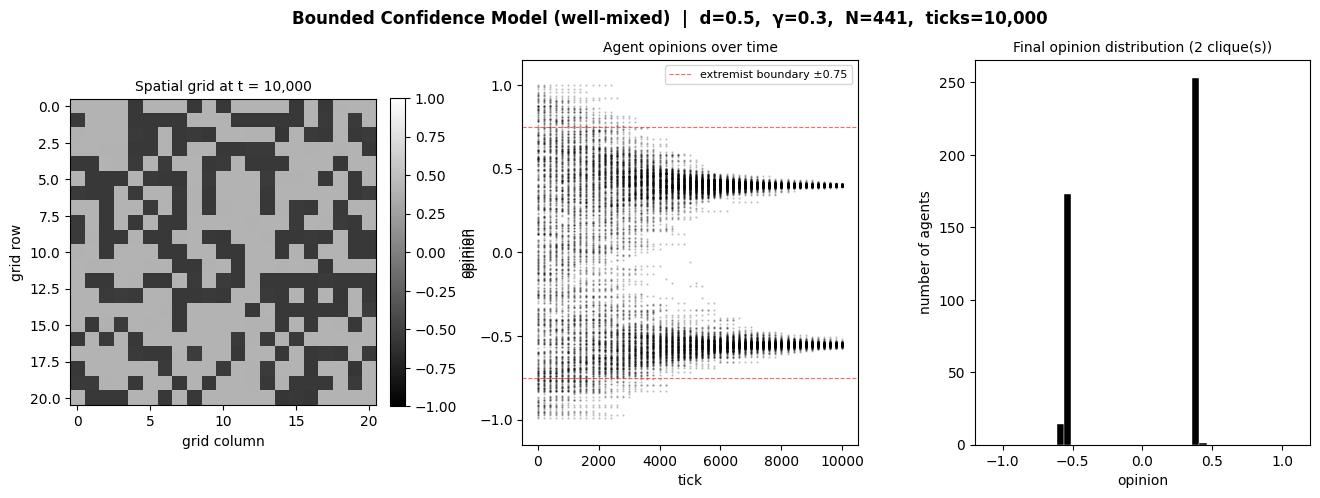

In [7]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

mode = "spatial" if spatial_interactions else "well-mixed"
fig.suptitle(
    f"Bounded Confidence Model ({mode})  |  "
    f"d={confidence_threshold},  γ={learning_rate},  N={N},  ticks={n_ticks:,}",
    fontsize=12, fontweight='bold'
)

# ── PANEL 1: SPATIAL GRID ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

opinion_grid = opinions.reshape(L, L)    # local: reshape flat array to 2D for display
im = ax1.imshow(
    opinion_grid, cmap='gray', vmin=-1, vmax=1,
    interpolation='nearest', aspect='equal'
)
ax1.set_title(f"Spatial grid at t = {n_ticks:,}", fontsize=10)
ax1.set_xlabel("grid column")
ax1.set_ylabel("grid row")
plt.colorbar(im, ax=ax1, label='opinion', fraction=0.046, pad=0.04)

# ── PANEL 2: SCATTERPLOT — OPINIONS OVER TIME ────────────────────────────────
ax2 = fig.add_subplot(gs[1])

t_pts  = [h[0] for h in history]    # local: time axis
op_pts = [h[2] for h in history]    # local: opinion axis

ax2.scatter(t_pts, op_pts, s=0.4, alpha=0.2, color='black')

# Mark the extremist boundary in red — agents outside this zone are loners
eb = 1 - 0.5 * confidence_threshold    # local: extremist boundary value
ax2.axhline( eb, color='red', lw=0.8, ls='--', alpha=0.6,
             label=f'extremist boundary ±{eb:.2f}')
ax2.axhline(-eb, color='red', lw=0.8, ls='--', alpha=0.6)

ax2.set_title("Agent opinions over time", fontsize=10)
ax2.set_xlabel("tick")
ax2.set_ylabel("opinion")
ax2.set_ylim(-1.15, 1.15)
ax2.legend(fontsize=8)

# ── PANEL 3: HISTOGRAM ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])

ax3.hist(opinions, bins=40, range=(-1.02, 1.02),
         color='black', edgecolor='white', linewidth=0.3)
ax3.set_title(f"Final opinion distribution ({c} clique(s))", fontsize=10)
ax3.set_xlabel("opinion")
ax3.set_ylabel("number of agents")
ax3.set_xlim(-1.2, 1.2)

plt.show()


---
## 8. Variance Over Time — Does BC Reach Consensus?

In Exercise 5.2 (positive influence only), variance always converged to zero —
consensus was guaranteed. Here we compare the variance trajectory for BC with
what we saw before.

**What to expect:**
- With large `d`: variance still drops toward zero (consensus, like positive influence)
- With moderate `d`: variance drops and then **plateaus** at a non-zero value —
  this is the signature of stable cliques. The within-clique variance is near zero,
  but the between-clique spread keeps the total variance elevated.
- With small `d`: variance may remain quite high if many cliques persist

The final non-zero variance is directly related to the number and spread of cliques.


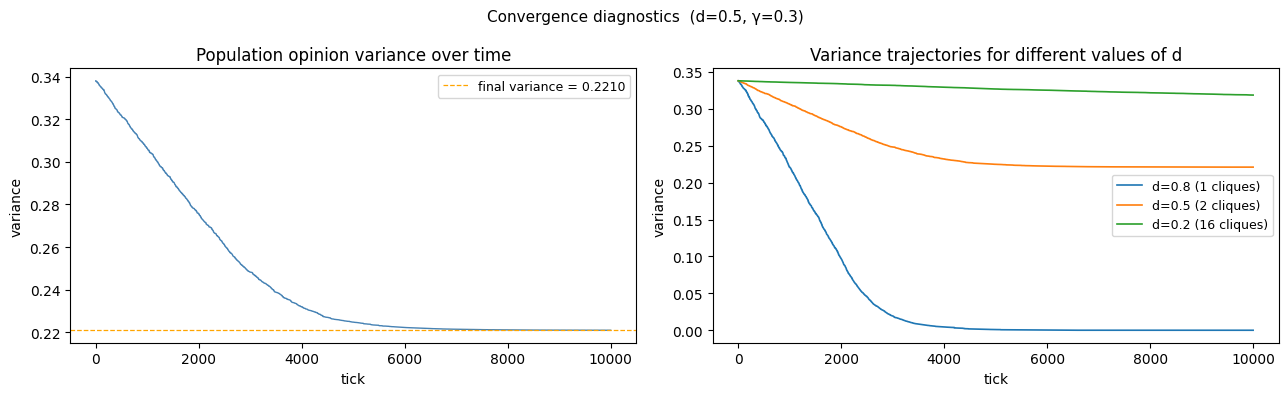

In [8]:
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4))
fig2.suptitle(f"Convergence diagnostics  (d={confidence_threshold}, γ={learning_rate})",
              fontsize=11)

tick_axis = np.arange(len(var_traj))    # local: x-axis values

# ── VARIANCE TRAJECTORY ──────────────────────────────────────────────────────
axes2[0].plot(tick_axis, var_traj, color='steelblue', lw=1.0)
axes2[0].set_title("Population opinion variance over time")
axes2[0].set_xlabel("tick")
axes2[0].set_ylabel("variance")
axes2[0].axhline(var_traj[-1], color='orange', lw=0.9, ls='--',
                 label=f'final variance = {var_traj[-1]:.4f}')
axes2[0].legend(fontsize=9)

# ── COMPARE THREE d VALUES ───────────────────────────────────────────────────
# Run three short simulations to show how d shapes convergence
compare_d = [0.8, 0.5, 0.2]    # local: d values for comparison

for dval in compare_d:
    ops_cmp, nbr_cmp = initialize(L, seed=42)    # local: fresh opinions
    _, var_cmp = run_simulation(
        ops_cmp, nbr_cmp,
        gamma=learning_rate, d=dval,
        n_ticks=n_ticks, record_every=record_every,
        spatial_interactions=False, seed=42
    )
    c_cmp = count_cliques(ops_cmp, dval)         # local: clique count
    axes2[1].plot(var_cmp, lw=1.2, label=f'd={dval} ({c_cmp} cliques)')

axes2[1].set_title("Variance trajectories for different values of d")
axes2[1].set_xlabel("tick")
axes2[1].set_ylabel("variance")
axes2[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## 9. Batch Experiment — Cliques vs. Confidence Threshold (Figure 5.4A)

This exactly replicates the batch experiment specified in the book's XML:

| Parameter | Value |
|---|---|
| `d` sweep | 0.02 to 1.0, step 0.02 (50 values) |
| Replications per `d` | 30 |
| Ticks per run | 80,000 |
| Learning rate γ | 0.5 |
| `spatial_interactions` | False (well-mixed) |

**Why 80,000 ticks?**  
Cliques can take a long time to fully stabilize, especially for small `d` where the
population fragments into many groups and each group needs time to internally converge.
80,000 ticks gives sufficient time for stable clique structure to emerge across all
values of `d` tested.

**Why γ = 0.5 for the batch run?**  
The book uses γ = 0.5 here because the learning rate affects convergence speed
(faster with higher γ) but not the final number of cliques. Using 0.5 means the
80,000 tick budget is sufficient even for small `d` values.

> ⚠️ **Runtime note:** 30 × 50 = 1,500 simulations at 80,000 ticks each.
> This will take several minutes. To get a fast preview, reduce `batch_reps` to 5
> and `batch_ticks` to 20,000 — the trend will still be visible.


In [9]:
# ── BATCH EXPERIMENT PARAMETERS ─────────────────────────────────────────────
# Matching the XML experiment block exactly

batch_d_values = np.arange(0.02, 1.02, 0.02)   # global: 50 values from 0.02 to 1.0
batch_reps     = 30                              # global: replications per d value
batch_ticks    = 80_000                          # global: ticks per run
batch_gamma    = 0.5                             # global: learning rate for batch

print(f"d values   : {batch_d_values[0]:.2f} to {batch_d_values[-1]:.2f}, "
      f"{len(batch_d_values)} values")
print(f"Reps per d : {batch_reps}")
print(f"Total runs : {len(batch_d_values) * batch_reps:,}")
print(f"Ticks each : {batch_ticks:,},  γ = {batch_gamma}")


d values   : 0.02 to 1.00, 50 values
Reps per d : 30
Total runs : 1,500
Ticks each : 80,000,  γ = 0.5


In [10]:
# ── RUN THE BATCH ────────────────────────────────────────────────────────────

# Outer loop: replications (so the tqdm bar shows overall progress clearly)
# Inner loop: d values (so each rep covers the full d sweep before moving on)
# This matches how the book's BehaviorSpace runs: each rep is a complete sweep.

# results_raw[d_val] = list of clique counts across all reps
results_raw = {float(round(dv, 4)): [] for dv in batch_d_values}   # local collector

for rep in tqdm(range(batch_reps), desc="Replications"):
    for dv in batch_d_values:
        dv_key = float(round(dv, 4))    # local: dict key (avoid float precision issues)

        # Fresh initialization — different seed per rep so we sample diverse initial
        # conditions, but the same set of seeds is used across all d values within
        # a rep (so any systematic effect of d is not confounded with initialization)
        ops_b, nbr_b = initialize(L, seed=rep * 1000 + int(dv * 1000))  # local

        # Run the BC model to convergence
        _, _ = run_simulation(
            ops_b, nbr_b,
            gamma=batch_gamma, d=dv,
            n_ticks=batch_ticks,
            record_every=batch_ticks + 1,    # never snapshot mid-run (saves memory)
            spatial_interactions=False,
            seed=rep
        )

        # Record the number of cliques at the end of this run
        results_raw[dv_key].append(count_cliques(ops_b, dv))   # local: one data point

print("Batch complete!")


Replications:   0%|          | 0/30 [00:00<?, ?it/s]

Batch complete!


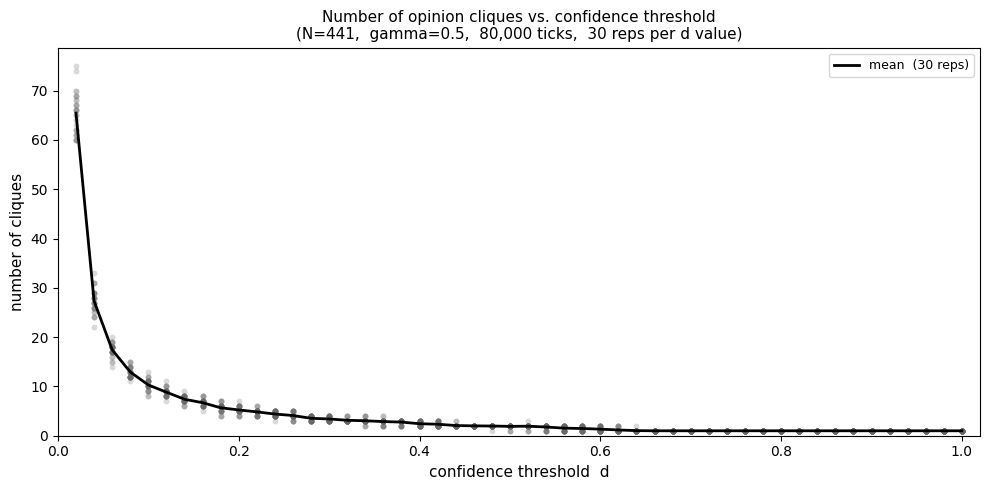


     d      mean    min    max     std
--------------------------------------
  0.10     10.30      8     13    1.16
  0.20      5.23      4      7    0.72
  0.30      3.40      3      4    0.49
  0.40      2.43      2      3    0.50
  0.50      1.90      1      2    0.30
  0.60      1.33      1      2    0.47
  0.70      1.00      1      1    0.00
  0.80      1.00      1      1    0.00


In [12]:
# ── PLOT FIGURE 5.4A ─────────────────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(10, 5))

d_keys = sorted(results_raw.keys())   # local: sorted d values for x-axis

# Individual run dots (open circles, semi-transparent — matching the book's style)
for dv in d_keys:
    ax3.scatter(
        [dv] * batch_reps,
        results_raw[dv],
        s=18, alpha=0.25, color='dimgray',
        linewidths=0, zorder=2
    )

# Mean line (connects mean clique count across 30 reps for each d)
means = [np.mean(results_raw[dv]) for dv in d_keys]   # local: means per d
ax3.plot(d_keys, means, color='black', lw=2.0, zorder=3,
         label=f'mean  ({batch_reps} reps)')

title_str = (
    f"Number of opinion cliques vs. confidence threshold\n"
    f"(N={N},  gamma={batch_gamma},  {batch_ticks:,} ticks,  "
    f"{batch_reps} reps per d value)"
)
ax3.set_title(title_str, fontsize=11)
ax3.set_xlabel("confidence threshold  d", fontsize=11)
ax3.set_ylabel("number of cliques", fontsize=11)
ax3.set_xlim(0.0, 1.02)
ax3.set_ylim(bottom=0)
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Summary table for key d values
print(f"\n{'d':>6}  {'mean':>8}  {'min':>5}  {'max':>5}  {'std':>6}")
print("-" * 38)
for dv in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    key = float(round(dv, 4))
    if key in results_raw:
        r = results_raw[key]
        print(f"  {dv:.2f}  {np.mean(r):>8.2f}  {min(r):>5}  {max(r):>5}  {np.std(r):>6.2f}")

---
## 10. Spatial BC Model (Section 5.3.3)

Now we switch on `spatial_interactions = True`. Agents can only interact with
their four von Neumann neighbors, so opinions must percolate slowly through the
local network rather than jumping anywhere in the population.

**What changes:**
- Convergence takes much longer (opinions propagate locally)
- For large `d`: still usually reaches consensus, but more slowly
- For small `d`: produces one dominant cluster plus isolated individuals or small
  clusters with no nearby similar neighbors — **much more diversity** than the
  well-mixed case, because many agents simply never find a suitable partner

Run the cell below with different values of `d` to explore. Compare the spatial
grid pattern to the well-mixed case from Section 7.

## Interpreting the result

### Well-mixed (left column)
**Scatterplot (top-left):** The population converges to 2 cliques — one near +0.4 and one near −0.5. Notice how the spread collapses quickly: by around tick 5,000, both bands have stabilized into tight horizontal lines. The agents outside the red dashed lines (the extremist boundary at ±0.75) are loners who never found a partner within their threshold.

**Spatial grid (bottom-left):** Even though the model is well-mixed (interactions are random), the final grid looks patchy and random — two shades of gray jumbled together with no geographic structure. This makes perfect sense: since agents interact with anyone regardless of location, where you sit on the grid has no effect on where you end up in opinion space. The two cliques are spatially scrambled.

### Spatial (right column)
**Scatterplot (top-right):** The spatial model produced 6 cliques and they have not fully converged even after 20,000 ticks. You can see the spread still slowly narrowing at the right edge of the plot—many agents are still moving. This matches the book's prediction: spatial interactions slow convergence dramatically because opinions must percolate through local channels rather than jumping anywhere.

**Spatial grid (bottom-right):** This is the key difference. Instead of random patchwork, you can see geographic zones—regions of similar shade that cluster together. Neighboring agents pulled each other toward agreement, creating spatial patches. The isolated white and near-black dots scattered around are the loners—agents whose neighbors were all too different for influence to fire.


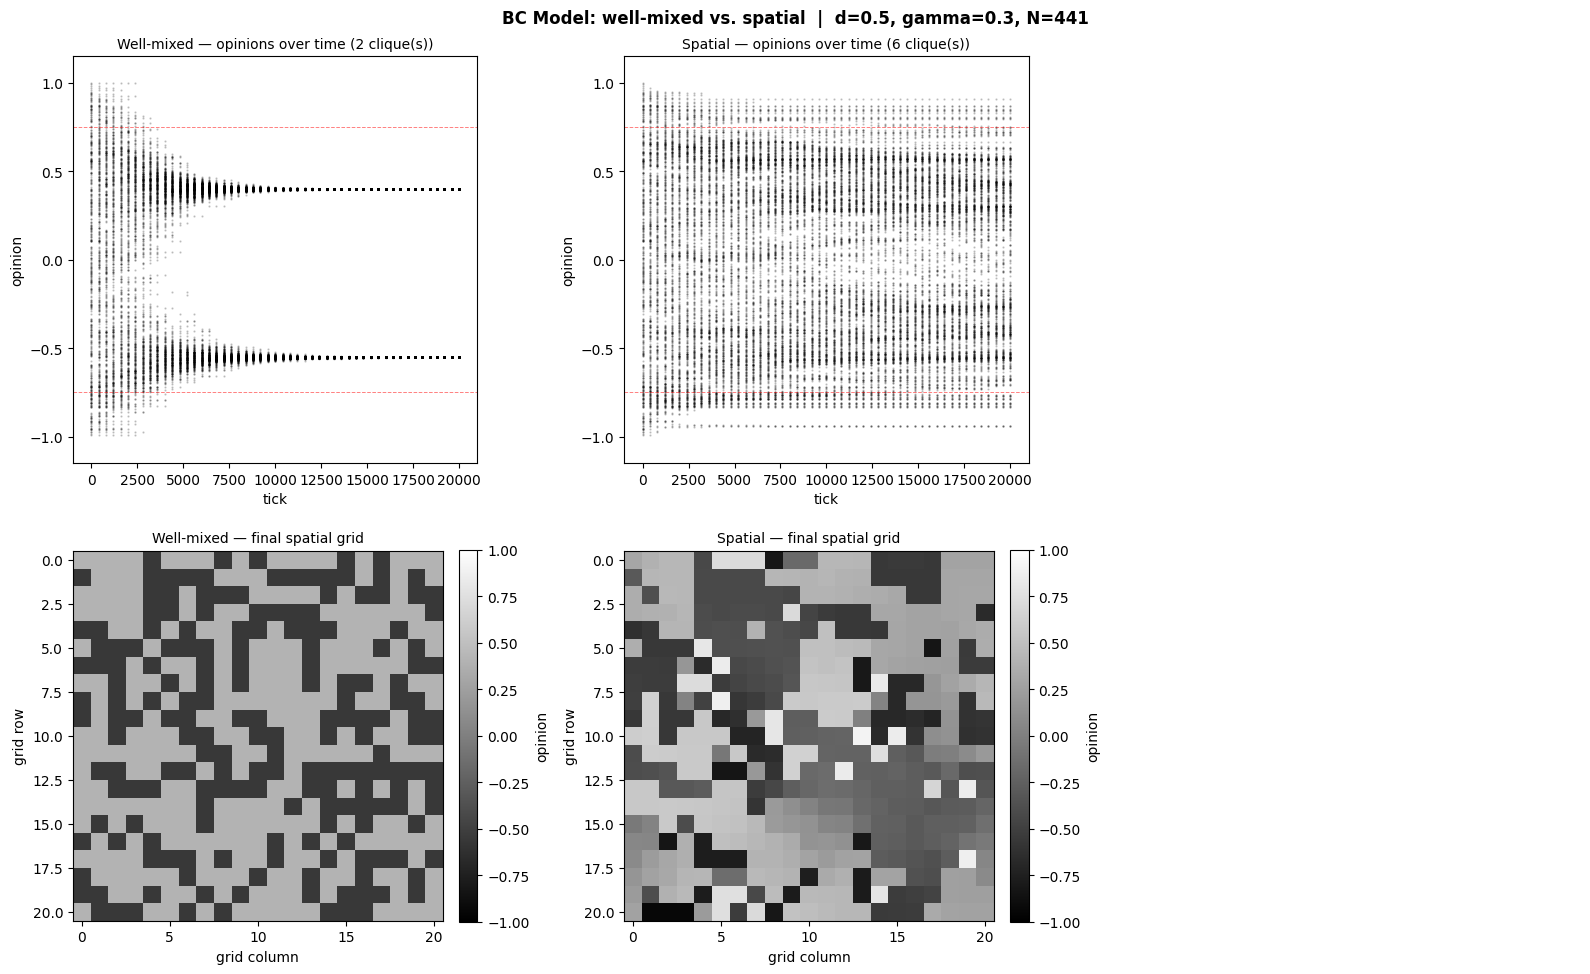

In [14]:
# ── SPATIAL MODEL COMPARISON ─────────────────────────────────────────────────
# Run both well-mixed and spatial versions side-by-side for the same d value

d_spatial   = 0.5      # local: d value for this comparison
ticks_sp    = 20_000   # local: more ticks since spatial converges slower

fig4, axes4 = plt.subplots(2, 3, figsize=(16, 10))
fig4.suptitle(
    f"BC Model: well-mixed vs. spatial  |  d={d_spatial}, gamma={learning_rate}, N={N}",
    fontsize=12, fontweight='bold'
)

for col, (use_spatial, label) in enumerate([(False, "Well-mixed"), (True, "Spatial")]):

    # Note: only 2 columns used — col goes 0 and 1
    ops_s, nbr_s = initialize(L, seed=42)    # local: fresh opinions
    hist_s, _    = run_simulation(
        ops_s, nbr_s,
        gamma=learning_rate, d=d_spatial,
        n_ticks=ticks_sp, record_every=400,
        spatial_interactions=use_spatial,
        seed=42
    )
    c_s = count_cliques(ops_s, d_spatial)    # local: clique count

    row_ax = axes4[:, col]   # local: the two rows for this column

    # ── Scatterplot (top row) ────────────────────────────────────────────────
    t_s  = [h[0] for h in hist_s]   # local
    op_s = [h[2] for h in hist_s]   # local
    row_ax[0].scatter(t_s, op_s, s=0.4, alpha=0.2, color='black')
    eb_s = 1 - 0.5 * d_spatial      # local: extremist boundary
    row_ax[0].axhline( eb_s, color='red', lw=0.7, ls='--', alpha=0.5)
    row_ax[0].axhline(-eb_s, color='red', lw=0.7, ls='--', alpha=0.5)
    row_ax[0].set_title(f"{label} — opinions over time ({c_s} clique(s))", fontsize=10)
    row_ax[0].set_xlabel("tick")
    row_ax[0].set_ylabel("opinion")
    row_ax[0].set_ylim(-1.15, 1.15)

    # ── Spatial grid (bottom row) ────────────────────────────────────────────
    grid_s = ops_s.reshape(L, L)     # local
    im_s = row_ax[1].imshow(
        grid_s, cmap='gray', vmin=-1, vmax=1,
        interpolation='nearest', aspect='equal'
    )
    row_ax[1].set_title(f"{label} — final spatial grid", fontsize=10)
    row_ax[1].set_xlabel("grid column")
    row_ax[1].set_ylabel("grid row")
    plt.colorbar(im_s, ax=row_ax[1], label='opinion', fraction=0.046, pad=0.04)

# Hide the unused third column panels
axes4[0, 2].axis('off')
axes4[1, 2].axis('off')

plt.tight_layout()
plt.show()


---
## 11. Summary and Key Takeaways

### What the model showed

| Parameter | Effect on number of cliques |
|---|---|
| Large `d` (close to 1) | 1 clique — near-consensus, similar to positive influence |
| Moderate `d` (≈ 0.3–0.6) | Few cliques — stable opinion fragmentation |
| Small `d` (≈ 0.05–0.2) | Many cliques — high fragmentation; also more extremists |

### Why bounded confidence breaks consensus

The key mechanism: once two agents' opinions are separated by more than `d`, they
can **never** reduce that gap. Their gap can only stay the same or grow (through
interactions with other agents). So any separation that exceeds `d` is permanent.
The BC model allows such separations to appear naturally through the stochastic
process of who interacts with whom early in the run — hence path dependency.

### Spatial vs. well-mixed

| Aspect | Well-mixed | Spatial |
|---|---|---|
| Convergence speed | Faster | Slower (local percolation only) |
| For large d | Consensus | Consensus, but slower |
| For small d | Several roughly equal cliques | One dominant cluster + isolated factions |
| Overall diversity | Less | More (agents may never find a suitable neighbor) |

### Variable type reference for this model

| Variable | Type | Role |
|---|---|---|
| `opinions` | Agent variable | Each agent's current opinion in $[-1, 1]$ |
| `L, N, learning_rate, confidence_threshold` | Global variables | Simulation settings |
| `spatial_interactions` | Global toggle | Well-mixed vs. neighbors-only |
| `neighbor_map` | Global structure | Precomputed von Neumann neighbors |
| `x1, x2, gap, i, j` | Local variables | Temporary values inside update / loop |
| `history, var_over_time` | Output (local to `run_simulation`) | Recorded data |
